In [2]:
!pip install ultralytics pycocotools kaggle -q

In [3]:
import json, os

kaggle_config = {
    "username": "Usuario",
    "key": "Token"
}
kaggle_dir = os.path.expanduser('~/.kaggle')
os.makedirs(kaggle_dir, exist_ok=True)
with open(f'{kaggle_dir}/kaggle.json', 'w') as f:
    json.dump(kaggle_config, f)
os.chmod(f'{kaggle_dir}/kaggle.json', 0o600)

!kaggle datasets download -d ammarnassanalhajali/pklot-dataset
!unzip -q pklot-dataset.zip -d pklot
!ls pklot

Dataset URL: https://www.kaggle.com/datasets/ammarnassanalhajali/pklot-dataset
License(s): unknown
pklot-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)
replace pklot/README.dataset.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: ^C
README.dataset.txt   test   train.cache  valid.cache
README.roboflow.txt  train  valid


In [5]:
import json, os
from pathlib import Path

def coco_to_yolo(json_path, output_dir):
    with open(json_path) as f:
        data = json.load(f)

    leaf_cats = [cat for cat in data['categories']
                 if cat['supercategory'] != 'none']
    categories = {cat['id']: i for i, cat in enumerate(leaf_cats)}
    print(f"Mapeamento: {categories}")
    print(f"Classes: {[cat['name'] for cat in leaf_cats]}")

    images = {img['id']: img for img in data['images']}
    ann_by_image = {}
    for ann in data['annotations']:
        ann_by_image.setdefault(ann['image_id'], []).append(ann)

    os.makedirs(output_dir, exist_ok=True)
    for img_id, img_info in images.items():
        W, H = img_info['width'], img_info['height']
        fname = Path(img_info['file_name']).stem
        lines = []
        for ann in ann_by_image.get(img_id, []):
            if ann['category_id'] not in categories:
                continue
            cls = categories[ann['category_id']]
            x, y, bw, bh = ann['bbox']
            xc = (x + bw/2) / W
            yc = (y + bh/2) / H
            lines.append(f"{cls} {xc:.6f} {yc:.6f} {bw/W:.6f} {bh/H:.6f}")
        with open(os.path.join(output_dir, fname + '.txt'), 'w') as f:
            f.write('\n'.join(lines))

base = 'pklot'
for split in ['train', 'valid', 'test']:
    coco_to_yolo(f'{base}/{split}/_annotations.coco.json',
                 f'{base}/{split}/labels')
    n = len(os.listdir(f'{base}/{split}/labels'))
    print(f"{split}: {n} labels ✅")

Mapeamento: {1: 0, 2: 1}
Classes: ['space-empty', 'space-occupied']
train: 8691 labels ✅
Mapeamento: {1: 0, 2: 1}
Classes: ['space-empty', 'space-occupied']
valid: 2483 labels ✅
Mapeamento: {1: 0, 2: 1}
Classes: ['space-empty', 'space-occupied']
test: 1242 labels ✅


In [6]:
import os

base_path = os.path.abspath('pklot')

yaml_content = f"""
path: {base_path}
train: train
val: valid
test: test

nc: 2
names:
  0: Vazio
  1: Ocupado
"""

with open('parking.yaml', 'w') as f:
    f.write(yaml_content)

print(f"✅ parking.yaml criado!")
print(f"Path: {base_path}")

✅ parking.yaml criado!
Path: /home/csdojunior/pklot


In [37]:
%%writefile rodar_cluster.sh
#!/bin/bash
#SBATCH --job-name=retomada_rtdetr
#SBATCH --partition=gpu-8-v100
#SBATCH --nodes=1
#SBATCH --ntasks-per-node=1
#SBATCH --gres=gpu:1
#SBATCH --mem=32G
#SBATCH --time=08:00:00
#SBATCH --output=resultado_treino.log
#SBATCH --error=erros_treino.log

export CUDA_DEVICE_ORDER=PCI_BUS_ID
export CUDA_VISIBLE_DEVICES=0

echo "🟢 Iniciando o processo de retomada no nó de GPU..."
python treinar_rtdetr.py

Overwriting rodar_cluster.sh


In [36]:
%%writefile treinar_rtdetr.py
from ultralytics import RTDETR

# Carrega o modelo base pré-treinado (padrão para novos treinos)
model = RTDETR("rtdetr-l.pt")

# Inicia o treinamento
model.train(
    data="parking.yaml",
    epochs=100,
    imgsz=640,
    device=0
)

Overwriting treinar_rtdetr.py


In [38]:
!rm -f resultado_treino.log erros_treino.log
!/usr/bin/sbatch rodar_cluster.sh

Submitted batch job 1896608


📊 Exibindo: results.png


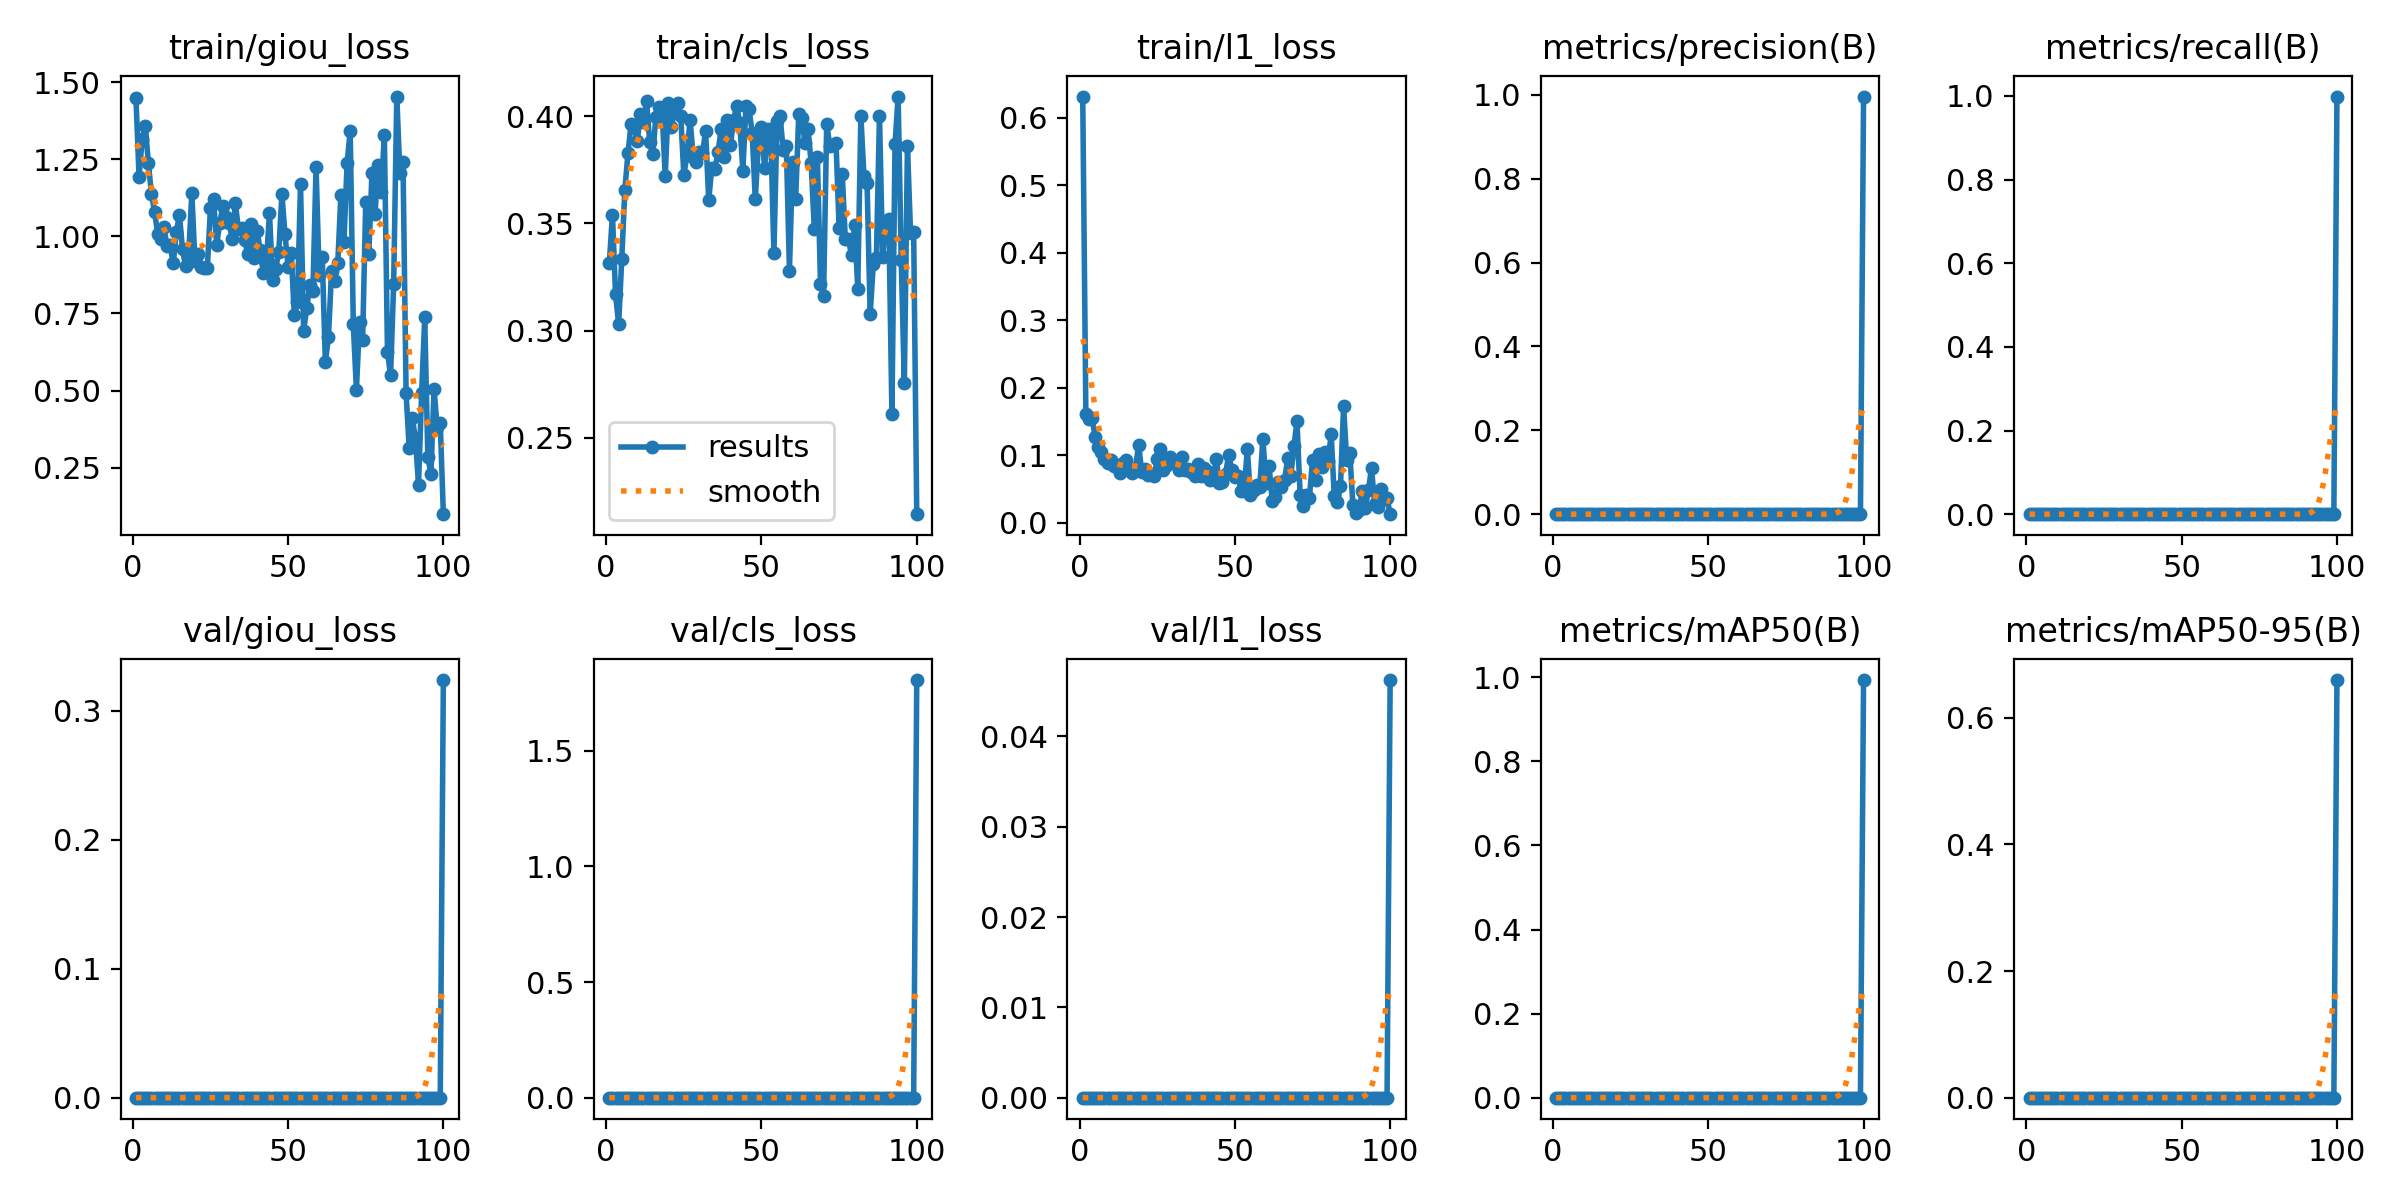

📊 Exibindo: confusion_matrix.png


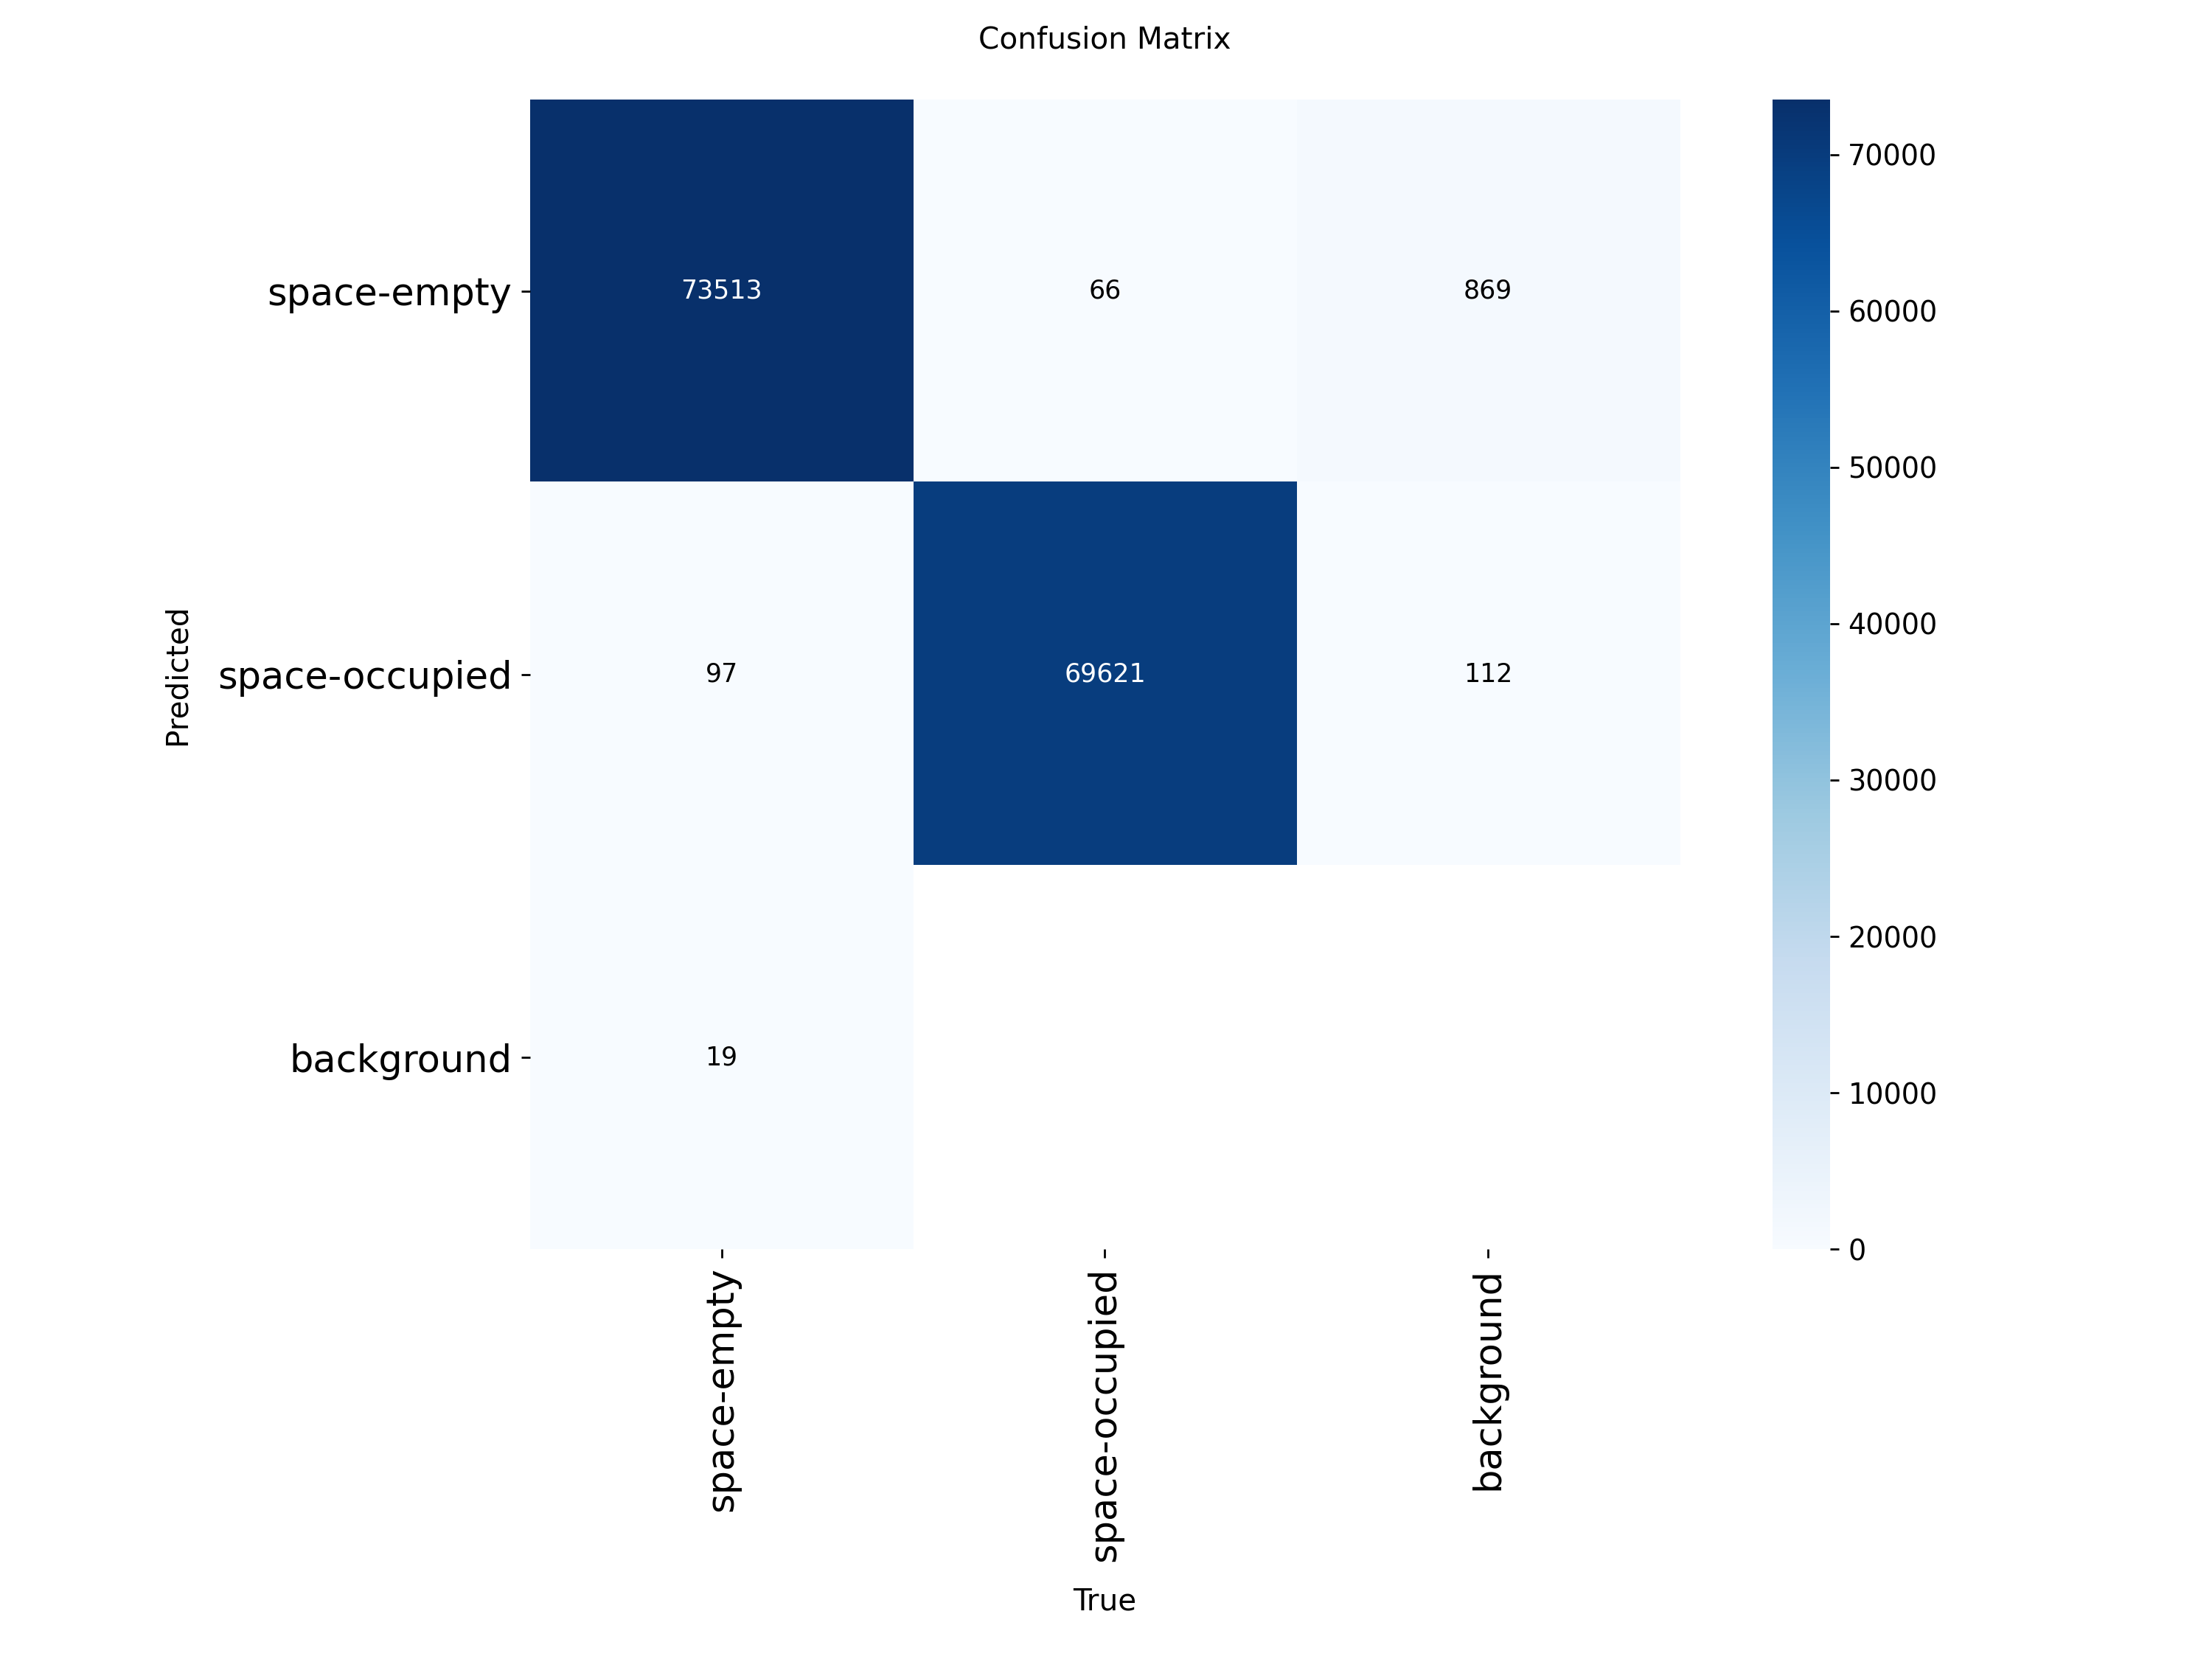

❌ F1_curve.png não encontrado na pasta.


In [47]:
from IPython.display import Image, display
import os

# Caminho da pasta onde o treino foi salvo
pasta_resultados = "runs/detect/train-4"

# Lista de gráficos importantes para você analisar
graficos = ["results.png", "confusion_matrix.png", "F1_curve.png"]

for grafico in graficos:
    caminho_completo = os.path.join(pasta_resultados, grafico)
    if os.path.exists(caminho_completo):
        print(f"📊 Exibindo: {grafico}")
        display(Image(filename=caminho_completo))
    else:
        print(f"❌ {grafico} não encontrado na pasta.")

In [48]:
import pandas as pd

# Carrega a tabela de resultados
df = pd.read_csv("runs/detect/train-4/results.csv")

# Remove espaços em branco do nome das colunas
df.columns = df.columns.str.strip()

# Mostra as últimas linhas (o resultado final na época 100)
display(df.tail())

,epoch,time,train/giou_loss,train/cls_loss,train/l1_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/giou_loss,val/cls_loss,val/l1_loss,lr/pg0,lr/pg1,lr/pg2,lr/pg3,lr/pg4,lr/pg5,lr/pg6,lr/pg7
95,96,19052.0,0.23096,0.27556,0.02394,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.001785,0.000595,0.001785,0.000595,0.001785,0.000595,0.001785,0.000595
96,97,19837.7,0.50574,0.38622,0.05030,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.001488,0.000496,0.001488,0.000496,0.001488,0.000496,0.001488,0.000496
97,98,20616.4,0.38236,0.34552,0.03493,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.001191,0.000397,0.001191,0.000397,0.001191,0.000397,0.001191,0.000397
98,99,22199.2,0.39412,0.34614,0.03666,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.000894,0.000298,0.000894,0.000298,0.000894,0.000298,0.000894,0.000298
99,100,23032.2,0.09929,0.21442,0.01258,0.99589,0.99856,0.99332,0.65982,0.32393,1.80627,0.04623,0.000597,0.000199,0.000597,0.000199,0.000597,0.000199,0.000597,0.000199
